# Binary Classification: Product Purchase Prediction

## Dataset
**File:** `social_network_ads.csv`

## Columns
- `user_id` — Unique identifier for each user
- `gender` — Gender of the user
- `age` — Age of the user
- `estimated_salary` — Estimated salary of the user
- `purchased` — Target variable (0 = No purchase, 1 = Purchase)

## Task
Build a **logistic regression model** to predict whether a user will purchase the product based on age, gender, and estimated salary.

## Evaluation Metrics
- Precision
- Recall
- Other classification metrics (Accuracy, F1-Score, ROC-AUC)

In [1]:
# Load all the necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries are successfully imported")

All libraries are successfully imported


# Task 1 : Data preparation and exploratory analysis
- Import and load the data from `social_network_ads.csv` file using pandas
- Display the number of rows and columns in the dataset
- Display the first few rows of the dataset to get an overview.
- Check for any missing values in the dataset and handle them appropriately.
- Visualise the distribution of user's age and estimated salary using scatter plots

In [2]:
#Load the data
df = pd.read_csv('social_network_ads.csv')
print(df)

      user_id  gender  age  estimated_salary  purchased
0    15624510    Male   19             19000          0
1    15810944    Male   35             20000          0
2    15668575  Female   26             43000          0
3    15603246  Female   27             57000          0
4    15804002    Male   19             76000          0
..        ...     ...  ...               ...        ...
395  15691863  Female   46             41000          1
396  15706071    Male   51             23000          1
397  15654296  Female   50             20000          1
398  15755018    Male   36             33000          0
399  15594041  Female   49             36000          1

[400 rows x 5 columns]


In [3]:
#Display the number of rows and columns in the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   user_id           400 non-null    int64
 1   gender            400 non-null    str  
 2   age               400 non-null    int64
 3   estimated_salary  400 non-null    int64
 4   purchased         400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB


In [4]:
#Display the first few rows of the dataset to get an overview
df.head()

,user_id,gender,age,estimated_salary,purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [6]:
#Check for any missing values in the dataset and handle them appropriately.
df.isnull().values.any()

np.False_

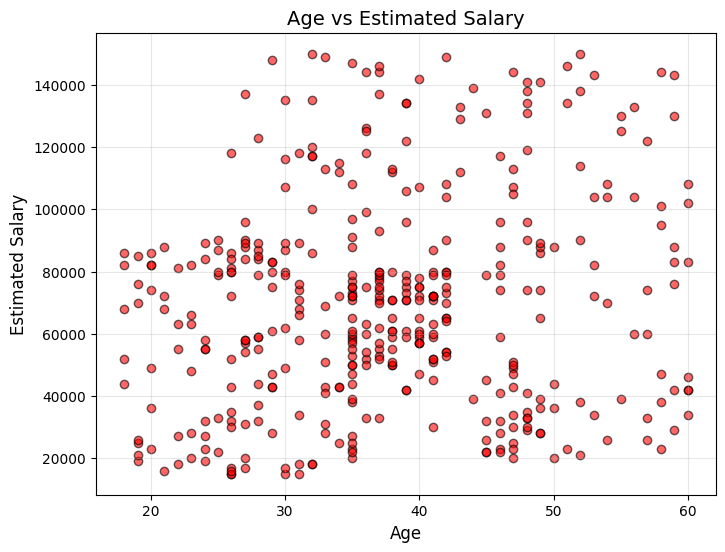

In [8]:
#Visualise the distribution of user's age and estimated salary using scatter plot
# With better formatting
plt.figure(figsize=(8, 6))
plt.scatter(df["age"], df["estimated_salary"], color="red", alpha=0.6, edgecolors='black')
plt.title("Age vs Estimated Salary", fontsize=14)
plt.xlabel("Age", fontsize=12)
plt.ylabel("Estimated Salary", fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

# Task 2: Model Training Using Logistic Regression
- Encode the `gender` column(Male as 0 and Female as 1)
- Select the features `(age,estimated_salary,gender)` and the target variable `(purchased)` for modelling.
- Split the data into training and test sets with a test size of `30%`
- Initialise and train the Logistic Regression Model using the training data.
- Print the model's coefficients and intercept.

In [9]:
#Encode the gender column (Male as 0, and Female as 1)
df['gender'] = df['gender'].map({'Male':0,'Female':1})
print(df.head())

    user_id  gender  age  estimated_salary  purchased
0  15624510       0   19             19000          0
1  15810944       0   35             20000          0
2  15668575       1   26             43000          0
3  15603246       1   27             57000          0
4  15804002       0   19             76000          0


In [10]:
#Select the features (age,estimated_salary,gender) and the target variable (purchased) for modelling.
X = df[['age','estimated_salary','gender']]
y = df['purchased']

In [11]:
#Split the data into training and test sets with a test size of 30%
from sklearn.model_selection import train_test_split
X_train,X_test, y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [12]:
#Initialise and train the Logistic Regression Model using the training data
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [13]:
#Print the model's coefficient and intercept
intercept = model.intercept_
coef = model.coef_
print(f"Intercept is found to be {intercept} and the coefficient is found to be {coef}")

Intercept is found to be [-10.88919901] and the coefficient is found to be [[ 1.99914592e-01  3.33049170e-05 -2.49140886e-01]]


# Task 3: Model Evaluation and Metrics
- Make the predictions on the test set using the trained model
- Evaluate the model using a classification report, including precision, recall and accuracy metrics

In [15]:
#Predictions
y_pred = model.predict(X_test)

In [17]:
#Evaluate the model using a classification report, including precision and accuracy metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(f"Accuracy Report: ",accuracy_score(y_test,y_pred))

Accuracy Report:  0.8583333333333333


In [18]:
print(f"Confusion Matrix: ",confusion_matrix(y_test,y_pred))

Confusion Matrix:  [[71  2]
 [15 32]]


In [19]:
print(f"Accuracy Metrics: ",classification_report(y_test,y_pred))

Accuracy Metrics:                precision    recall  f1-score   support

           0       0.83      0.97      0.89        73
           1       0.94      0.68      0.79        47

    accuracy                           0.86       120
   macro avg       0.88      0.83      0.84       120
weighted avg       0.87      0.86      0.85       120

